In [10]:
# S&P 500 Market Analysis & Machine Learning

# This notebook analyzes historical S&P 500 data, builds a machine learning model to predict next-day price, direction, and simulates a basic trading strategy to evaluate model performance.

In [11]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, classification_report

In [12]:
import yfinance as yf
import pandas as pd

# Get Data
sp500 = yf.download("^GSPC", start="2022-01-01")

sp500 = sp500[['Close']]

sp500.columns = ['Price']
sp500['Price'] = sp500['Price'].values

print(type(sp500['Price']))
sp500.head()

[*********************100%***********************]  1 of 1 completed

<class 'pandas.Series'>


,Price
Date,
2022-01-03,4796.560059
2022-01-04,4793.540039
2022-01-05,4700.580078
2022-01-06,4696.049805
2022-01-07,4677.029785


In [13]:
# Returns
sp500['Return'] = sp500['Price'].pct_change()

# Averages
sp500['MA_20'] = sp500['Price'].rolling(20).mean()
sp500['MA_50'] = sp500['Price'].rolling(50).mean()

# Volatility
sp500['Volatility'] = sp500['Return'].rolling(20).std()

# Momentum
sp500['Momentum'] = sp500['Price'] - sp500['MA_20']

# Target
sp500['Target'] = (sp500['Return'].shift(-1) > 0).astype(int)

sp500 = sp500.dropna()

sp500.head()

,Price,Return,MA_20,MA_50,Volatility,Momentum,Target
Date,,,,,,,
2022-03-15,4262.450195,0.021409,4309.348975,4453.883174,0.015958,-46.898779,1
2022-03-16,4357.859863,0.022384,4303.688477,4445.109170,0.016397,54.171387,1
2022-03-17,4411.669922,0.012348,4300.521484,4437.471768,0.016670,111.148438,1
2022-03-18,4463.120117,0.011662,4304.664502,4432.722568,0.016144,158.455615,0
2022-03-21,4461.180176,-0.000435,4310.280005,4428.025176,0.016033,150.900171,1


In [14]:
X = sp500[['Return', 'MA_20', 'MA_50', 'Volatility', 'Momentum']]
y = sp500['Target']

split = int(len(sp500) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [15]:
preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

Accuracy: 0.46798029556650245
              precision    recall  f1-score   support

           0       0.45      0.92      0.61        91
           1       0.61      0.10      0.17       112

    accuracy                           0.47       203
   macro avg       0.53      0.51      0.39       203
weighted avg       0.54      0.47      0.37       203



In [16]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)

Return        0.216308
Momentum      0.213078
MA_20         0.191548
Volatility    0.189713
MA_50         0.189353
dtype: float64

In [17]:
sp500_test = sp500.iloc[split:].copy()
sp500_test['Prediction'] = preds

sp500_test['Strategy_Return'] = sp500_test['Return'] * sp500_test['Prediction']

sp500_test['Market_Return'] = (1 + sp500_test['Return']).cumprod()
sp500_test['Strategy_Growth'] = (1 + sp500_test['Strategy_Return']).cumprod()

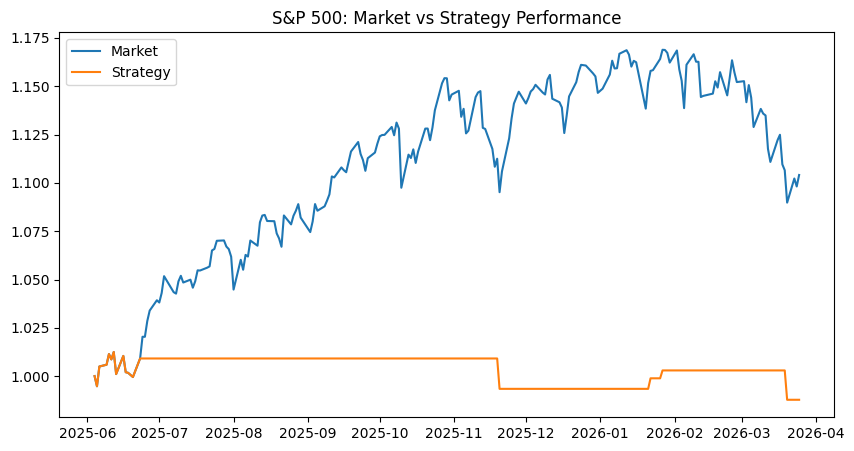

In [18]:
plt.figure(figsize=(10,5))
plt.plot(sp500_test['Market_Return'], label='Market')
plt.plot(sp500_test['Strategy_Growth'], label='Strategy')
plt.legend()
plt.title("S&P 500: Market vs Strategy Performance")
plt.show()